# SurvivalNet Demo

This notebook demonstrates an end-to-end workflow using the TCGA expression matrix and the paired clinical survival table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from survivalnet import CoxModel, fit_km, plot_grouped_km_with_pvalue, split_risk_group
from survivalnet.models import LassoCoxModel
from survivalnet.io import load_clinical_data, normalize_survival_data

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

base_dir = Path("examples")
expr_path = None
clinical_path = None
for candidate in [base_dir / "data_mrna_seq_v2_rsem.txt", Path("data_mrna_seq_v2_rsem.txt"), Path("../examples/data_mrna_seq_v2_rsem.txt")]:
    if candidate.exists():
        expr_path = candidate
        break
for candidate in [base_dir / "data_clinical_patient.txt", Path("data_clinical_patient.txt"), Path("../examples/data_clinical_patient.txt")]:
    if candidate.exists():
        clinical_path = candidate
        break

if expr_path is None:
    raise FileNotFoundError("Could not find examples/data_mrna_seq_v2_rsem.txt")
if clinical_path is None:
    raise FileNotFoundError("Could not find examples/data_clinical_patient.txt")

print(f"Using expression file: {expr_path.resolve()}")
print(f"Using clinical file: {clinical_path.resolve()}")

Using expression file: /home/zengj/bio2503/survivalnet/SurvivalNet/examples/data_mrna_seq_v2_rsem.txt
Using clinical file: /home/zengj/bio2503/survivalnet/SurvivalNet/examples/data_clinical_patient.txt


In [2]:
# Read expression matrix and reshape it to sample x gene format.
expr_raw = pd.read_csv(expr_path, sep="\t", comment="#")
expr_raw = expr_raw.rename(columns={"Hugo_Symbol": "gene", "Entrez_Gene_Id": "entrez"})
expr_raw["gene"] = expr_raw["gene"].astype(str)

sample_cols = [c for c in expr_raw.columns if c not in ["gene", "entrez"]]
expr_long = expr_raw.melt(id_vars=["gene", "entrez"], value_vars=sample_cols, var_name="PATIENT_ID", value_name="expression")
expr_long["PATIENT_ID"] = expr_long["PATIENT_ID"].astype(str).str.slice(0, 12)
expr_long["expression"] = pd.to_numeric(expr_long["expression"], errors="coerce")
expr_long = expr_long.dropna(subset=["expression"])

expr_df = expr_long.pivot_table(index="PATIENT_ID", columns="gene", values="expression", aggfunc="mean")
expr_df = expr_df.reset_index()

display(expr_df.head())
print(f"Expression matrix reshaped to: {expr_df.shape}")

gene,PATIENT_ID,133K02,5T4,A-C1,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,...,ZWINT,ZWS1,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZZ3,nan
0,TCGA-05-4244,699.1884,860.8081,157.4308,26.0302,36.7711,0.000,9844.7858,10.5245,0.3491,...,517.6717,598.6561,39.7940,292.5212,959.2460,0.6981,1088.0531,2837.9440,575.2683,326.7301
1,TCGA-05-4249,463.9396,1641.9793,1.2878,120.1349,132.1439,0.322,25712.6617,20.3734,1.6098,...,287.5074,398.9044,62.1376,493.5597,1179.3275,20.2833,787.5061,2351.2500,690.2752,151.6416
2,TCGA-05-4250,331.2609,786.2058,9.9478,50.8597,69.3426,0.000,16943.6359,15.6611,0.0000,...,1046.8374,462.9031,60.0182,365.4149,843.9028,26.5274,475.1720,5437.4534,532.8691,270.5795
3,TCGA-05-4382,365.8960,1195.8028,47.3822,145.9037,111.1903,0.000,23326.2727,49.6748,4.7861,...,753.0902,387.4334,40.4424,346.7517,946.6872,64.8514,908.1593,6770.1537,663.8297,183.3070
4,TCGA-05-4384,465.4856,715.3329,18.9371,127.3671,138.7355,0.000,48314.5571,23.8668,0.0000,...,153.9401,456.3225,80.0244,563.2254,1320.7086,7.9414,778.8638,3341.4783,723.2743,130.7269


Expression matrix reshaped to: (515, 20515)


In [3]:
# Load and normalize clinical survival data, then merge by PATIENT_ID.
raw_clinical = load_clinical_data(str(clinical_path))
clinical = normalize_survival_data(raw_clinical, "OS_MONTHS", "OS_STATUS", id_col="PATIENT_ID")

data = clinical.merge(expr_df, on="PATIENT_ID", how="inner")
display(data[["PATIENT_ID", "duration", "event", "AGE", "INITIAL_PATHOLOGIC_DX_YEAR"]].head())
print(f"Merged rows: {len(data)}")
print(f"Merged columns: {len(data.columns)}")

成功读取数据，原始矩阵形状为: (522, 79)
删失数据标准化完成：有效样本 513 例 (剔除了 9 例缺失值)


,PATIENT_ID,duration,event,AGE,INITIAL_PATHOLOGIC_DX_YEAR
0,TCGA-05-4244,0.00,0,70,2009
1,TCGA-05-4249,50.03,0,67,2007
2,TCGA-05-4250,3.98,1,79,2007
3,TCGA-05-4382,19.94,0,68,2009
4,TCGA-05-4384,13.99,0,66,2009


Merged rows: 506
Merged columns: 20593


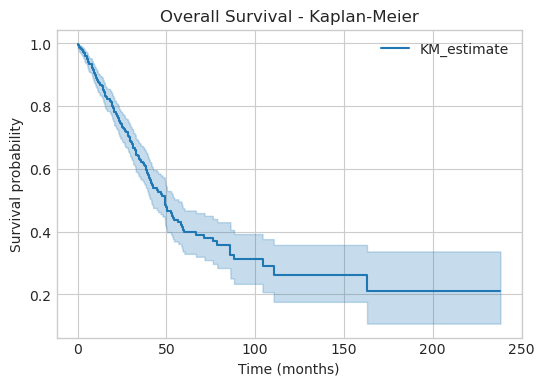

In [4]:
# Kaplan-Meier curve for the whole cohort.
kmf = fit_km(data, "duration", "event")
ax = kmf.plot_survival_function(figsize=(6, 4))
ax.set_title("Overall Survival - Kaplan-Meier")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival probability")
plt.show()

Rows used for Cox model: 496


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
AGE,0.008369,1.008405,0.007840,-0.006997,0.023736,0.993028,1.024019,0.0,1.067541,0.285728,1.807287
INITIAL_PATHOLOGIC_DX_YEAR,-0.025421,0.974900,0.015574,-0.055945,0.005103,0.945591,1.005116,0.0,-1.632271,0.102622,3.284582


,HR,CI_lower,CI_upper,p_value
covariate,,,,
AGE,1.008405,0.993028,1.024019,0.285728
INITIAL_PATHOLOGIC_DX_YEAR,0.974900,0.945591,1.005116,0.102622


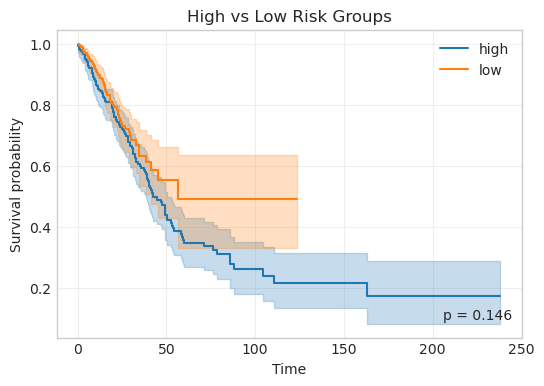

In [5]:
# Cox model demo using age and diagnosis year.
cox_df = data[["duration", "event", "AGE", "INITIAL_PATHOLOGIC_DX_YEAR"]].copy()
for col in ["AGE", "INITIAL_PATHOLOGIC_DX_YEAR"]:
    cox_df[col] = pd.to_numeric(cox_df[col], errors="coerce")
cox_df = cox_df.dropna()

print(f"Rows used for Cox model: {len(cox_df)}")

cox_model = CoxModel().fit(cox_df, "duration", "event")
display(cox_model.summary)
display(cox_model.hazard_ratios)

risk_scores = cox_model.predict_risk_score(cox_df)
cox_df["risk_group"] = split_risk_group(risk_scores)

ax = plot_grouped_km_with_pvalue(
    cox_df,
    duration_col="duration",
    event_col="event",
    group_col="risk_group",
    group_a="low",
    group_b="high",
)
ax.set_title("High vs Low Risk Groups")
plt.show()

Rows used for LASSO-Cox model: 506
Features used: ['SFTPB', 'ADAM6', 'SFTPA2', 'PGC', 'FN1', 'BMS1P20', 'COL1A1', 'FTL', 'SFTP1', 'H19']
开始进行 LASSO-Cox 回归，当前 penalizer (lambda) = 0.1
LASSO 筛选完成！从 10 个原始特征中筛选出 0 个核心预后特征。
Selected features: []


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
SFTPB,-6.115084e-13,1.0,3.300203e-10,-6.474394e-10,6.462164e-10,1.0,1.0,0.0,-0.001853,0.998522,0.002135
ADAM6,-7.354158e-13,1.0,4.244599e-10,-8.326615e-10,8.311907e-10,1.0,1.0,0.0,-0.001733,0.998618,0.001996
SFTPA2,-1.205390e-12,1.0,6.196064e-10,-1.215612e-09,1.213201e-09,1.0,1.0,0.0,-0.001945,0.998448,0.002241
PGC,-1.275396e-13,1.0,4.144133e-10,-8.123627e-10,8.121076e-10,1.0,1.0,0.0,-0.000308,0.999754,0.000354
FN1,1.700513e-13,1.0,6.558932e-10,-1.285357e-09,1.285697e-09,1.0,1.0,0.0,0.000259,0.999793,0.000298
BMS1P20,-1.682082e-12,1.0,9.491731e-10,-1.862027e-09,1.858663e-09,1.0,1.0,0.0,-0.001772,0.998586,0.002041
COL1A1,9.520482e-13,1.0,8.162975e-10,-1.598962e-09,1.600866e-09,1.0,1.0,0.0,0.001166,0.999069,0.001343
FTL,-4.267677e-13,1.0,7.679707e-10,-1.505622e-09,1.504768e-09,1.0,1.0,0.0,-0.000556,0.999557,0.000640
SFTP1,-2.296503e-12,1.0,1.211214e-09,-2.376232e-09,2.371639e-09,1.0,1.0,0.0,-0.001896,0.998487,0.002184


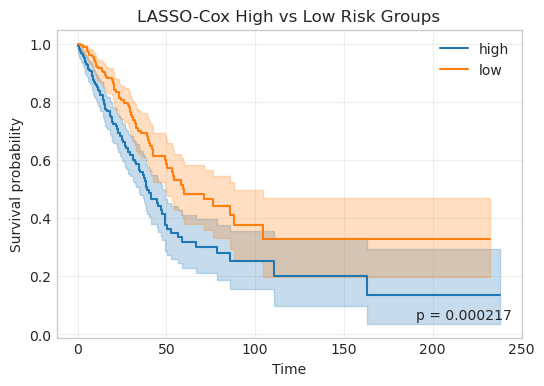

In [6]:
# LASSO-Cox demo using top-variance gene expression features.
# We select a small set of genes to keep the example light and stable.

gene_cols = [c for c in expr_df.columns if c != "PATIENT_ID"]
gene_variance = expr_df[gene_cols].var(numeric_only=True).sort_values(ascending=False)
top_genes = gene_variance.head(10).index.tolist()

lasso_df = data.set_index("PATIENT_ID")[["duration", "event"]].join(
    expr_df.set_index("PATIENT_ID")[top_genes],
    how="inner",
).reset_index()

for col in top_genes:
    lasso_df[col] = pd.to_numeric(lasso_df[col], errors="coerce")
    lasso_df[col] = lasso_df[col].fillna(lasso_df[col].median())

print(f"Rows used for LASSO-Cox model: {len(lasso_df)}")
print(f"Features used: {top_genes}")

lasso_model = LassoCoxModel(penalizer=0.1).fit(lasso_df, "duration", "event")
selected_features = lasso_model.selected_features
print("Selected features:", selected_features)

display(lasso_model.fitter.summary)

lasso_risk_scores = lasso_model.predict_risk_score(lasso_df)
lasso_df["risk_group"] = split_risk_group(lasso_risk_scores)

ax = plot_grouped_km_with_pvalue(
    lasso_df,
    duration_col="duration",
    event_col="event",
    group_col="risk_group",
    group_a="low",
    group_b="high",
)
ax.set_title("LASSO-Cox High vs Low Risk Groups")
plt.show()